# 07 - Joint TVP-SV

Estimates the time-varying coefficients $\theta_t$ **and** the stochastic
volatility $h_t=\log V_t$ **jointly** (PyMC/NUTS), the clean version of
notebooks 04 + 06. Each currency is a separate MCMC run: a reusable
`run_currency` function is called once per currency in its own block, so they
compute **one after another**.

$$
Y_t = F_t\,\theta_t + v_t,\ v_t\sim N(0,e^{h_t}),\qquad
\theta_t=\theta_{t-1}+w_t,\quad h_t=h_{t-1}+\eta_t
$$

Coefficient RW scale fixed by $\lambda$ (OLS-initialised); the volatility process
is estimated. Non-centered parameterisation.

> **Runtime & memory.** Each block is a full MCMC run. Start with `N_OBS = 1500`
> and `CHAINS = 4`; the full daily sample with a few thousand draws needs several
> minutes and substantial RAM *per currency*. Run the blocks one at a time.

## Setup

In [1]:
import os, ast
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt

CURRENCIES = ["CHF", "EUR", "GBP", "JPY"]
RATE = {"CHF": "CHF_3M", "EUR": "EUR_3M", "GBP": "GBP_3M", "JPY": "JPY_3M"}
REGRESSORS = ["SP500", "UST10Y", "fxvol", "TED", "VIX"]
TERMS = ["const"] + REGRESSORS

LAMBDA = 1e-3
DRAWS, TUNE, CHAINS = 1000, 1000, 4
N_OBS = None          

DATA_DIR = Path("..") / "data"
FIG_DIR = Path("..") / "figures"; FIG_DIR.mkdir(exist_ok=True)

# nutpie (Rust NUTS sampler) is 2-4x faster than PyMC's Python sampler and much
# lighter on memory -- both matter on a fanless MacBook Air. Falls back cleanly.
try:
    import nutpie  # noqa: F401
    NUTS_KWARGS = {"nuts_sampler": "nutpie"}
except ImportError:
    NUTS_KWARGS = {}
    print("nutpie not installed (pip install nutpie) -> PyMC's default sampler")

/home/vscode/.local/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


## Load and construct variables

Build the model inputs for all currencies and a helper for the Bai-Perron break
dates (overlaid on the coefficient figures).

In [2]:
levels = pd.read_csv(DATA_DIR / "levels.csv", index_col="date", parse_dates=True)
fx = levels[CURRENCIES].dropna()
appreciation = np.log(fx).diff()
sp500_d = np.log(levels["SP500"]).diff().rename("SP500")
vix_d = np.log(levels["VIX"]).diff().rename("VIX")
ust10y_d = levels["UST10Y"].diff().rename("UST10Y")
ted_d = ((levels["US_3M"] - levels["TBILL_3M"]) / 360).rename("TED")
# interbank rates are % p.a.; /100/360 gives the daily decimal carry
interest_diff = pd.DataFrame({cur: (levels[RATE[cur]] - levels["US_3M"]) / 100 / 360 for cur in CURRENCIES})
excess = appreciation + interest_diff
realized = np.log(appreciation.rolling(30).std())
fx_vol = pd.DataFrame({cur: realized[[o for o in CURRENCIES if o != cur]].mean(axis=1) for cur in CURRENCIES})
fx_vol = fx_vol - fx_vol.mean()   # centre log-vol so it does not offset the intercept

def model_frame(cur):
    return pd.concat([excess[cur].rename("excess"), sp500_d, ust10y_d,
                      fx_vol[cur].rename("fxvol"), ted_d, vix_d], axis=1).dropna()

def break_dates(cur):
    p = DATA_DIR / "break_dates.csv"
    if not p.exists(): return []
    raw = pd.read_csv(p, index_col=0)["break_dates"]
    return [pd.Timestamp(d) for d in ast.literal_eval(raw[cur])] if cur in raw.index else []

## Model runner

`run_currency` fits the joint TVP-SV model for one currency, prints a convergence
check, plots all coefficient paths and the volatility path, and saves the
posterior-mean coefficients. Each of the four blocks below calls it once.

In [3]:
import gc

results = {}

def run_currency(cur):
    df = model_frame(cur)
    if N_OBS:
        df = df.iloc[-N_OBS:]
    Y = df["excess"].values
    F = np.column_stack([np.ones(len(df))] + [df[r].values for r in REGRESSORS])
    n, k = F.shape
    ols = sm.OLS(Y, F).fit()
    C0 = ols.mse_resid * np.linalg.inv(F.T @ F)
    scale = np.sqrt(LAMBDA * np.diag(C0))
    theta0 = ols.params

    with pm.Model():
        tz = pm.Normal("tz", 0, 1, shape=(n, k))
        theta = theta0 + pt.cumsum(tz * scale, axis=0)
        sigma_eta = pm.HalfNormal("sigma_eta", 0.3)
        h0 = pm.Normal("h0", np.log(np.var(Y)), 2.0)
        hz = pm.Normal("hz", 0, 1, shape=n)
        h = h0 + sigma_eta * pt.cumsum(hz)
        mu = (F * theta).sum(axis=1)
        pm.Normal("obs", mu, pt.exp(h / 2), observed=Y)
        idata = pm.sample(DRAWS, tune=TUNE, chains=CHAINS,
                          cores=4,
                          target_accept=0.95, random_seed=1, progressbar=True,
                          **NUTS_KWARGS)

    try:
        rhat = float(az.summary(idata, var_names=["sigma_eta", "h0"])["r_hat"].max())
        print(f"{cur}: n={n}, max r-hat (sigma_eta, h0) = {rhat:.3f}")
    except Exception as ex:
        rhat = float("nan")
        print(f"{cur}: n={n}, r-hat check skipped ({ex})")

    bks = break_dates(cur)
    tz_all = idata.posterior["tz"].values.reshape(-1, n, k)

    # all coefficient paths
    fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharex=True)
    for ax, term in zip(axes.ravel(), TERMS):
        j = TERMS.index(term)
        d = theta0[j] + np.cumsum(tz_all[:, :, j] * scale[j], axis=1)
        m, lo, hi = d.mean(0), *np.percentile(d, [10, 90], axis=0)
        ax.plot(df.index, m, color="C0", lw=1.2)
        ax.fill_between(df.index, lo, hi, color="C0", alpha=0.2)
        ax.axhline(ols.params[j], color="grey", ls="--", lw=1)
        ax.axhline(0, color="black", lw=0.6)
        for dt in bks: ax.axvline(dt, color="red", ls=":", lw=0.8)
        ax.set_title(fr"$\theta_{{t,\mathrm{{{term}}}}}$")
    fig.suptitle(fr"{cur}: TVP-SV coefficient paths (posterior mean, 80% band)")
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"tvpsv_{cur}_coefs.png", dpi=300, bbox_inches="tight")
    plt.show()

    # volatility path
    h0d = idata.posterior["h0"].values.reshape(-1)
    sd_d = idata.posterior["sigma_eta"].values.reshape(-1)
    hz_d = idata.posterior["hz"].values.reshape(-1, n)
    vol = np.exp((h0d[:, None] + sd_d[:, None] * np.cumsum(hz_d, axis=1)) / 2)
    vm, vlo, vhi = vol.mean(0), *np.percentile(vol, [10, 90], axis=0)
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(df.index, vm, color="C3", lw=1.2, label="posterior mean $e^{h_t/2}$")
    ax.fill_between(df.index, vlo, vhi, color="C3", alpha=0.2, label="80% band")
    ax.legend(); ax.set_title(f"{cur}: stochastic-volatility path")
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"tvpsv_{cur}_vol.png", dpi=300, bbox_inches="tight")
    plt.show()

    tz_mean = idata.posterior["tz"].mean(("chain", "draw")).values
    theta_mean = pd.DataFrame(theta0 + np.cumsum(tz_mean * scale, axis=0),
                              index=df.index, columns=TERMS)
    theta_mean.to_csv(DATA_DIR / f"tvpsv_{cur}_coefficients.csv")
    # convergence diagnostics over all parameters -> saved per currency
    try:
        s = az.summary(idata)
        rh = pd.to_numeric(s["r_hat"], errors="coerce")
        eb = pd.to_numeric(s["ess_bulk"], errors="coerce")
        et = pd.to_numeric(s["ess_tail"], errors="coerce")
        pd.DataFrame([{
            "currency": cur, "n": n,
            "max_rhat": round(float(rh.max()), 4),
            "share_rhat>1.01": round(float((rh > 1.01).mean()), 4),
            "min_ess_bulk": int(eb.min()),
            "min_ess_tail": int(et.min()),
        }]).to_csv(DATA_DIR / f"tvpsv_{cur}_convergence.csv", index=False)
    except Exception as ex:
        print(f"  (convergence save skipped: {ex})")

    # free the ~1.3 GB posterior before the next currency; everything the
    # later cells need is already on disk (CSVs, figures, convergence)
    del idata, tz_all
    gc.collect()
    return {"rhat": rhat, "theta_mean": theta_mean}

## CHF

/home/vscode/.local/lib/python3.11/site-packages/pytensor/link/c/cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.01,511
,2000,0,0.01,511
,2000,0,0.01,511
,2000,0,0.01,511


CHF: n=5790, max r-hat (sigma_eta, h0) = 1.010


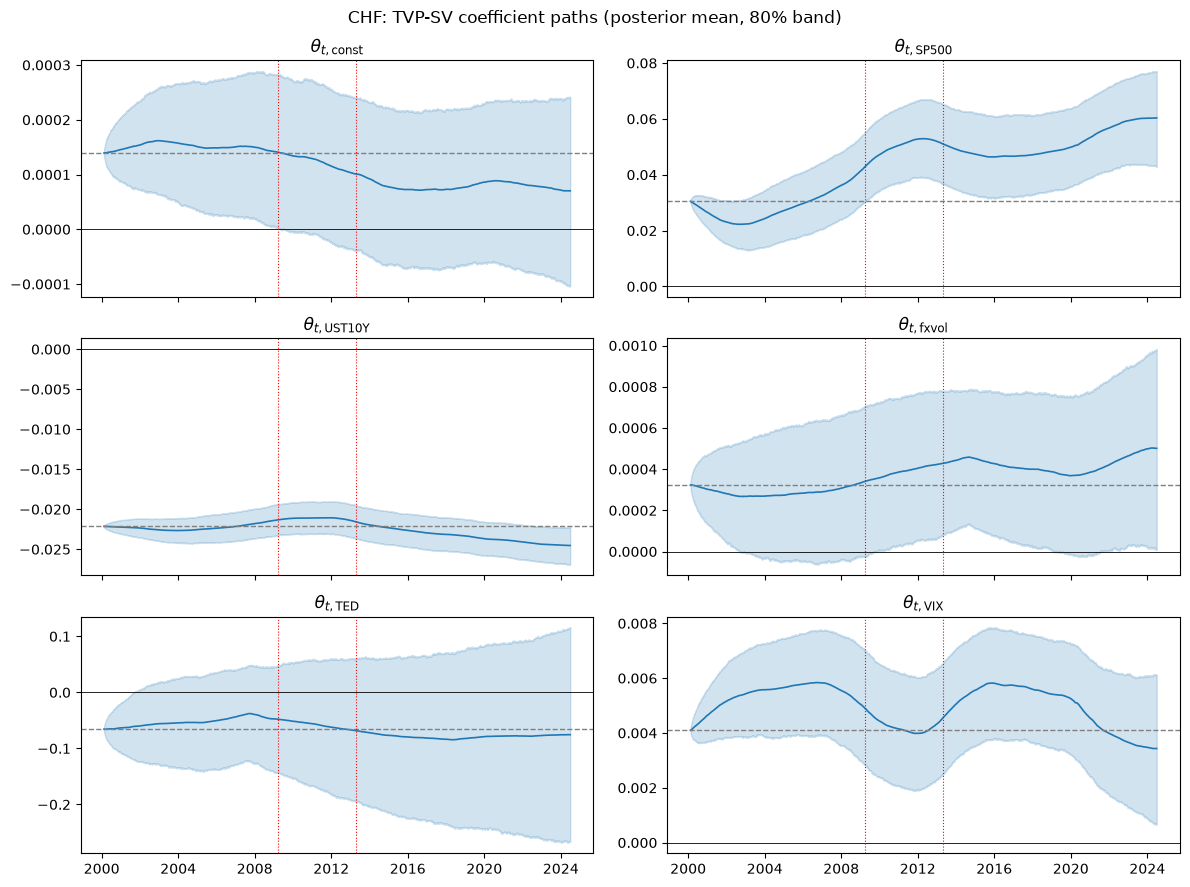

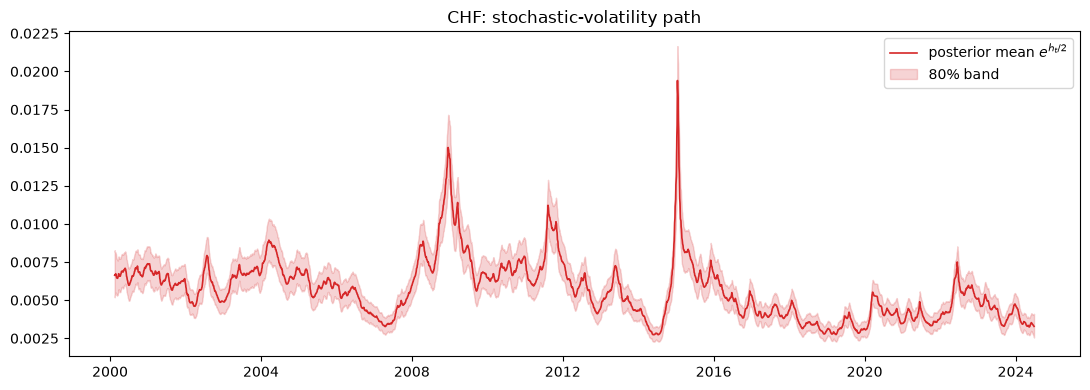

In [4]:
results["CHF"] = run_currency("CHF")

## EUR

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.01,511
,2000,0,0.01,511
,2000,0,0.01,511
,2000,0,0.01,511


EUR: n=5790, max r-hat (sigma_eta, h0) = 1.010


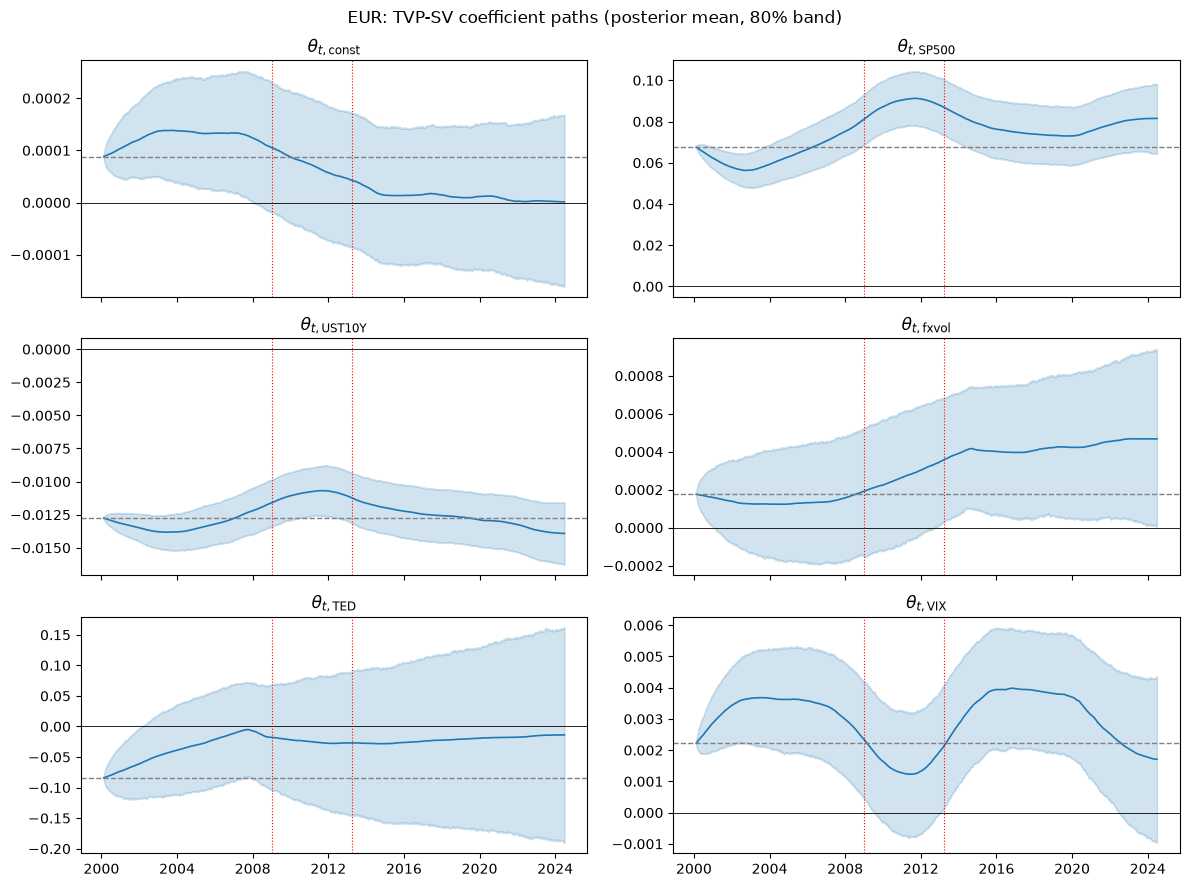

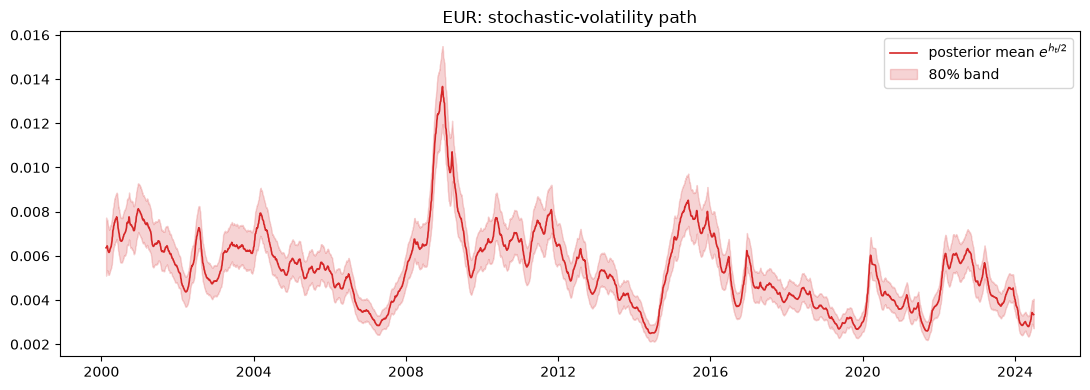

: 

In [ ]:
results["EUR"] = run_currency("EUR")

## GBP

/home/vscode/.local/lib/python3.11/site-packages/pytensor/link/c/cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.01,511
,2000,0,0.01,511
,2000,0,0.01,511
,2000,0,0.01,511


GBP: n=5790, max r-hat (sigma_eta, h0) = 1.040


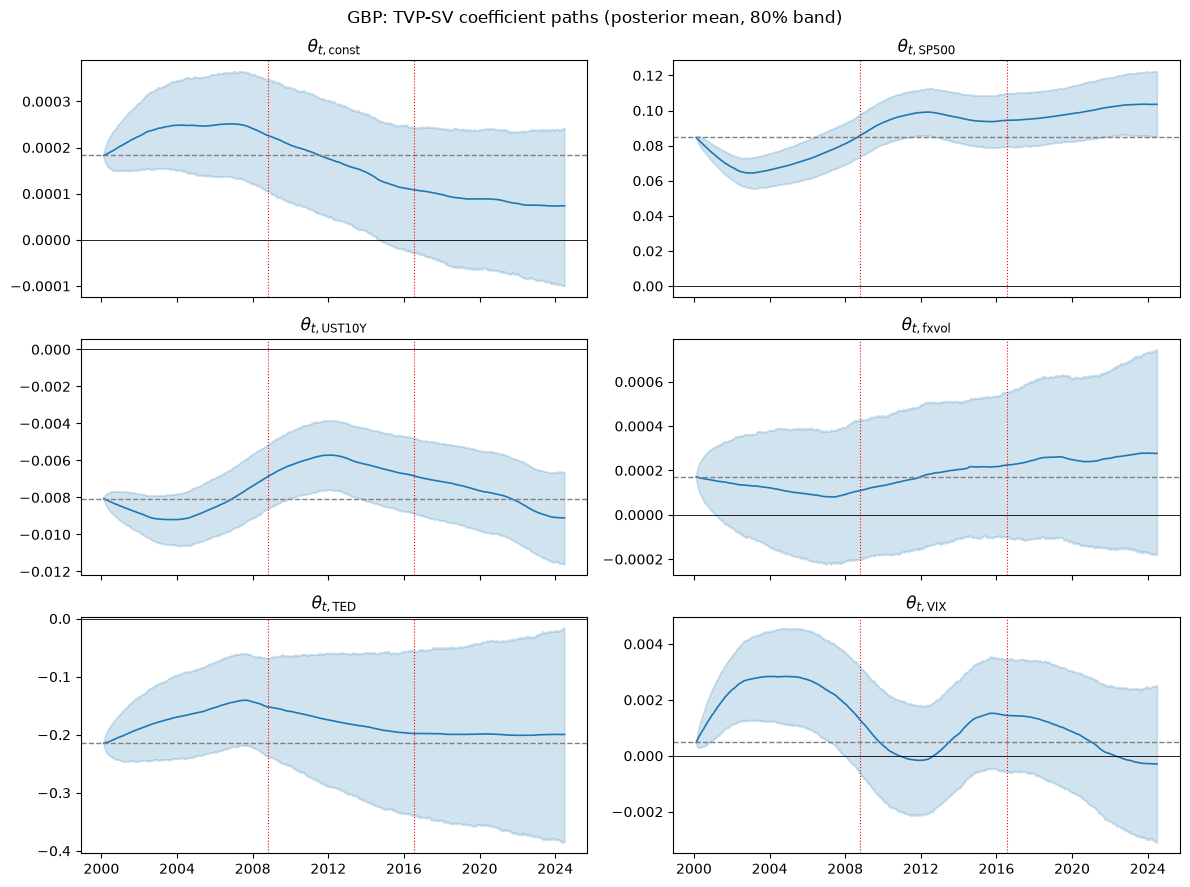

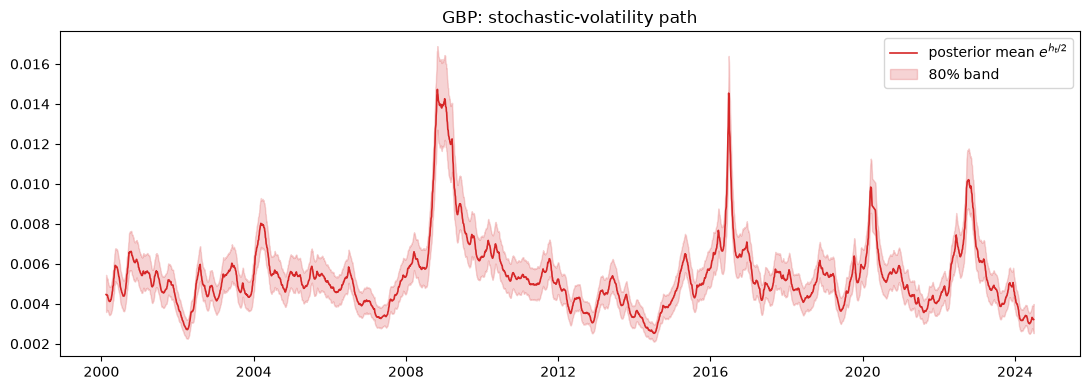

In [4]:
results["GBP"] = run_currency("GBP")

## JPY

/home/vscode/.local/lib/python3.11/site-packages/pytensor/link/c/cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.01,1023
,2000,0,0.01,511
,2000,0,0.01,511
,2000,0,0.01,1023


JPY: n=5286, max r-hat (sigma_eta, h0) = 1.010


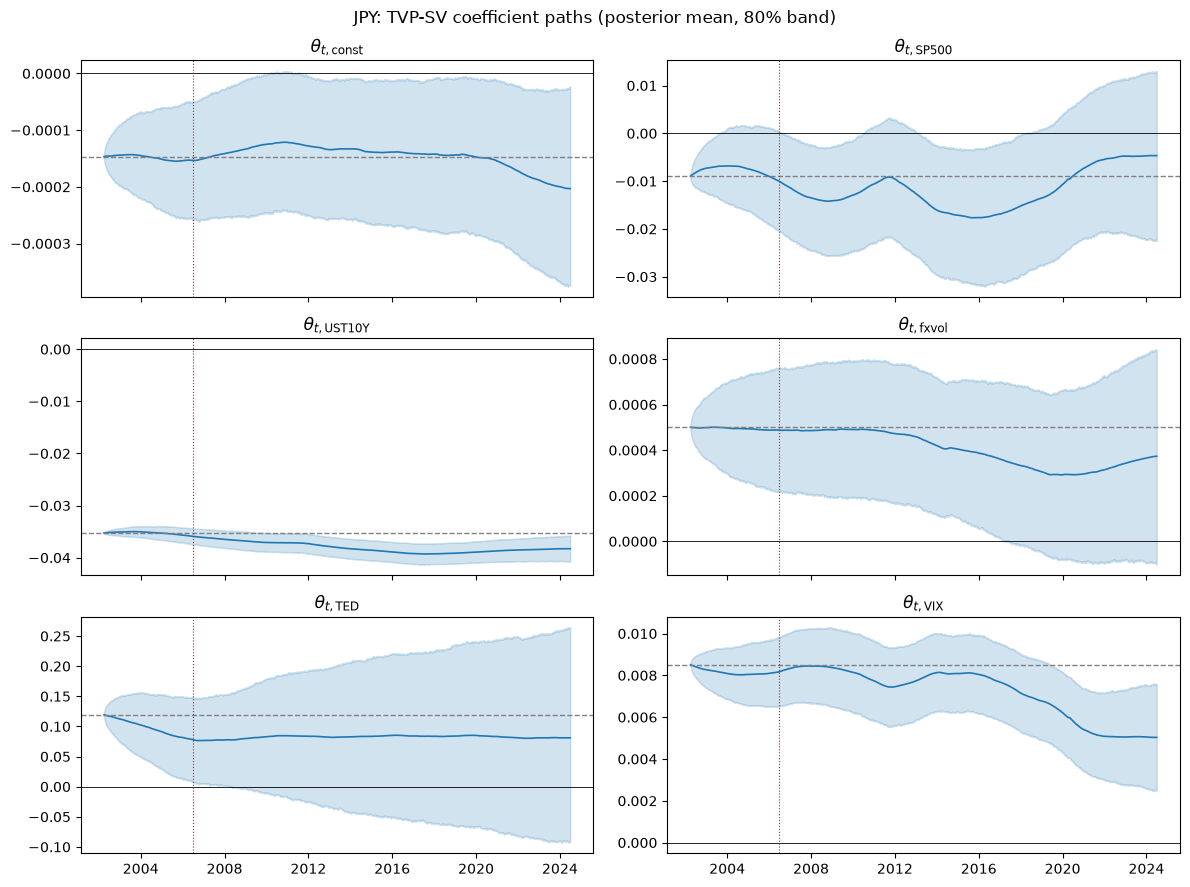

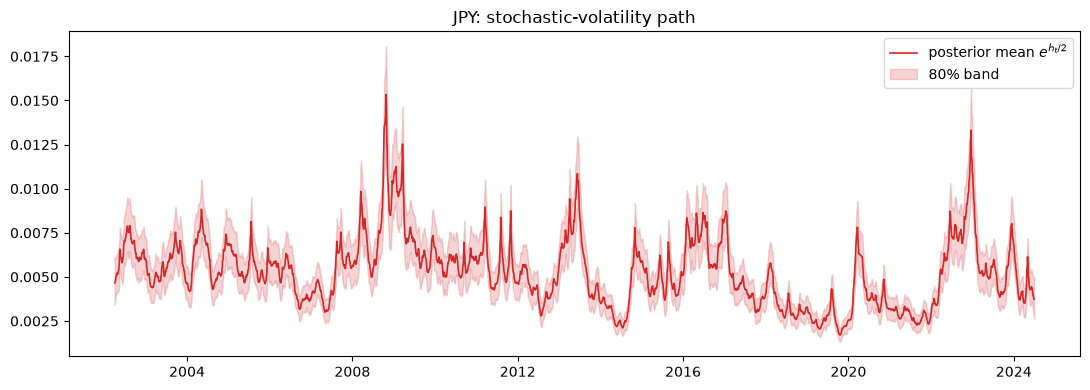

In [5]:
results["JPY"] = run_currency("JPY")

## Convergence check

Reads the per-currency diagnostics that each `run_currency` call saved to
`data/tvpsv_<CUR>_convergence.csv` (worst r-hat, share above 1.01, and minimum
ESS bulk/tail over all parameters). Because the numbers are written to disk as
each currency finishes, the four currencies can be run **one at a time** (memory-
safe) and still appear together here, no need to hold all chains in memory at
once.

Rule of thumb: max r-hat below ~1.05 with only a small share above 1.01, and min
ESS comfortably above ~400.

In [5]:
import glob

files = sorted(glob.glob(str(DATA_DIR / "tvpsv_*_convergence.csv")))
convergence = (pd.concat([pd.read_csv(f) for f in files], ignore_index=True).set_index("currency")
               if files else pd.DataFrame(
                   columns=["n", "max_rhat", "share_rhat>1.01", "min_ess_bulk", "min_ess_tail"]))
convergence

,n,max_rhat,share_rhat>1.01,min_ess_bulk,min_ess_tail
currency,,,,,
CHF,5790,1.01,0.0,213,367
EUR,5790,1.01,0.0,328,602
GBP,5790,1.01,0.0,1226,1815
JPY,5286,1.01,0.0,303,456


## Export convergence table to LaTeX

Reads the per-currency `tvpsv_<CUR>_convergence.csv` files and writes
`../paper/convergence.tex` for inclusion in the paper.

In [6]:
import glob
PAPER = Path("..") / "paper"; PAPER.mkdir(exist_ok=True)
files = sorted(glob.glob(str(DATA_DIR / "tvpsv_*_convergence.csv")))
if files:
    conv = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    L = [r"\begin{table}[H]", r"\centering",
         r"\caption{Joint TVP-SV convergence diagnostics (over all parameters): worst "
         r"$\hat R$, share above 1.01, and minimum effective sample size (bulk/tail).}",
         r"\label{tab:convergence}", r"\begin{tabular}{lrrrrr}", r"\toprule",
         r"Currency & N & max $\hat R$ & share $>1.01$ & min ESS bulk & min ESS tail \\", r"\midrule"]
    for _, r in conv.iterrows():
        L.append(f"{r['currency']} & {int(r['n'])} & ${r['max_rhat']:.3f}$ & "
                 f"${r['share_rhat>1.01']:.3f}$ & {int(r['min_ess_bulk'])} & {int(r['min_ess_tail'])} " + r"\\")
    L += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
    (PAPER / "convergence.tex").write_text("\n".join(L))
    print(f"Wrote {PAPER / 'convergence.tex'} ({len(conv)} currencies)")
else:
    print("No convergence files yet.")

Wrote ../paper/convergence.tex (4 currencies)
